<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/6_Regresi%C3%B3n_Lineal__Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Analisis GAC Full7agosto 2026(Leads por Canal).csv",header=None)


In [6]:
df.head(15)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,Leads por Canal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Meta,1280,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Canal,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,...,Obj Jun,Obj Historicos,Proyección,%,Aporte promedio,%,Ajuste,NaN,NaN,NaN
4,Piso,0,329,19,76,87,55,92,77,57,...,95,117,76,100%,69,6%,9.1%,NaN,NaN,NaN
5,Plazas,0,0,0,25,28,68,294,248,52,...,350,462,280,100%,273,22%,36.1%,NaN,NaN,NaN
6,Eventos,0,7,0,5,0,71,4,5,1,...,55,32,44,9%,19,2%,2.5%,NaN,NaN,NaN
7,Planta,0,6,52,127,60,376,237,135,1030,...,200,0,160,100%,465,38%,0.0%,NaN,NaN,NaN
8,Digitales,0,6,5,18,69,87,113,57,107,...,500,395,400,85%,234,19%,30.9%,NaN,NaN,NaN
9,Otros,0,195,102,165,178,310,214,887,68,...,80,274,64,100%,162,13%,21.4%,NaN,NaN,NaN


In [5]:
df.shape

(18, 41)

In [7]:
df_canales = df.iloc[4:10, 0:31].copy()

df_canales

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
4,Piso,0,329,19,76,87,55,92,77,57,...,58,72,81,76,105,94,105,79,113,85
5,Plazas,0,0,0,25,28,68,294,248,52,...,312,324,274,325,290,433,401,351,352,403
6,Eventos,0,7,0,5,0,71,4,5,1,...,1,14,46,42,89,4,89,1,0,1
7,Planta,0,6,52,127,60,376,237,135,1030,...,364,401,204,452,484,297,673,391,233,449
8,Digitales,0,6,5,18,69,87,113,57,107,...,312,287,350,405,438,338,307,443,427,299
9,Otros,0,195,102,165,178,310,214,887,68,...,53,94,106,234,93,107,103,128,114,78


In [8]:
meses_num = list(range(1, 31))

meses_num

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30]

In [10]:
registros = []

for _, fila in df_canales.iterrows():

    canal = fila.iloc[0]

    for mes_num in range(1, 31):

        leads = fila.iloc[mes_num]

        registros.append([mes_num, canal, leads])

In [11]:
df_leads = pd.DataFrame(registros, columns=["Mes_num", "Canal", "Leads"])

df_leads.head(20)

,Mes_num,Canal,Leads
0,1,Piso,0
1,2,Piso,329
2,3,Piso,19
3,4,Piso,76
4,5,Piso,87
5,6,Piso,55
6,7,Piso,92
7,8,Piso,77
8,9,Piso,57
9,10,Piso,43


In [12]:
df_leads.shape

(180, 3)

In [13]:
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Mes_num  180 non-null    int64
 1   Canal    180 non-null    str  
 2   Leads    180 non-null    str  
dtypes: int64(1), str(2)
memory usage: 4.3 KB


In [14]:
df_leads["Leads"] = pd.to_numeric(df_leads["Leads"],errors="coerce")

In [15]:
df_leads.info()
df_leads.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Mes_num  180 non-null    int64
 1   Canal    180 non-null    str  
 2   Leads    180 non-null    int64
dtypes: int64(2), str(1)
memory usage: 4.3 KB


Mes_num    0
Canal      0
Leads      0
dtype: int64

In [23]:
df_leads["Canal"].unique()

<StringArray>
['Piso ', 'Plazas ', 'Eventos ', 'Planta ', 'Digitales', 'Otros ']
Length: 6, dtype: str

In [24]:
df_leads["Canal"].value_counts()

Canal
Piso         30
Plazas       30
Eventos      30
Planta       30
Digitales    30
Otros        30
Name: count, dtype: int64

In [25]:
df_leads["Canal"] = df_leads["Canal"].astype(str).str.strip()

In [26]:
df_leads["Canal"].unique()

<StringArray>
['Piso', 'Plazas', 'Eventos', 'Planta', 'Digitales', 'Otros']
Length: 6, dtype: str

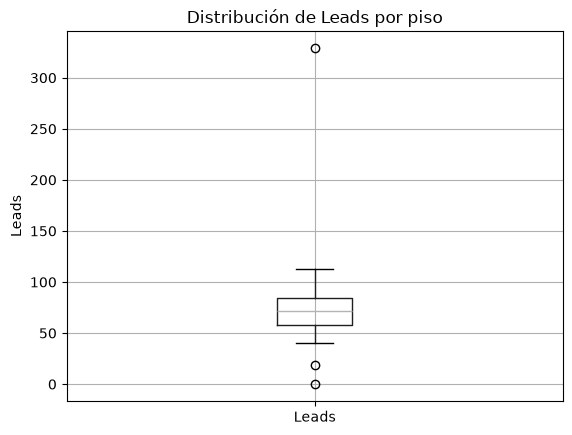

In [27]:
df_leads[df_leads["Canal"] == "Piso"].boxplot(column="Leads")

plt.title("Distribución de Leads por piso")
plt.ylabel("Leads")
plt.show()

In [28]:
# Identificamos los outliers del canal Piso

piso = df_leads[df_leads["Canal"] == "Piso"]["Leads"]

Q1 = piso.quantile(0.25)
Q3 = piso.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_piso = df_leads[(df_leads["Canal"] == "Piso") & ((df_leads["Leads"] < limite_inferior) |(df_leads["Leads"] > limite_superior))]

outliers_piso

,Mes_num,Canal,Leads
0,1,Piso,0
1,2,Piso,329
2,3,Piso,19


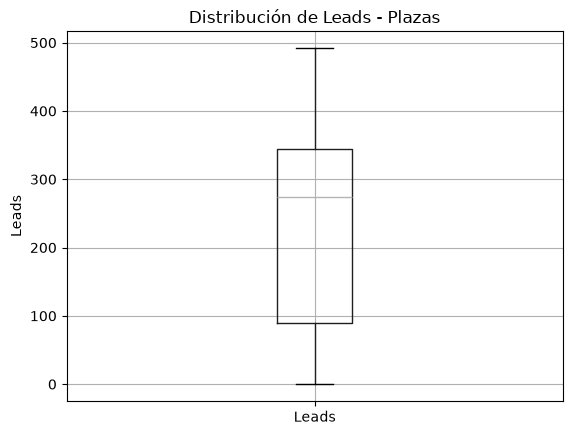

In [29]:
# Gráfico de caja para identificar outliers del canal Plazas

df_leads[df_leads["Canal"] == "Plazas"].boxplot(column="Leads")

plt.title("Distribución de Leads - Plazas")
plt.ylabel("Leads")

plt.show()

In [35]:
# Identificamos los outliers del canal Piso

plazas = df_leads[df_leads["Canal"] == "Plazas"]["Leads"]

Q1 = plazas.quantile(0.25)
Q3 = plazas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_plazas = df_leads[(df_leads["Canal"] == "Plazas") & ((df_leads["Leads"] < limite_inferior) |(df_leads["Leads"] > limite_superior))]

outliers_plazas

,Mes_num,Canal,Leads


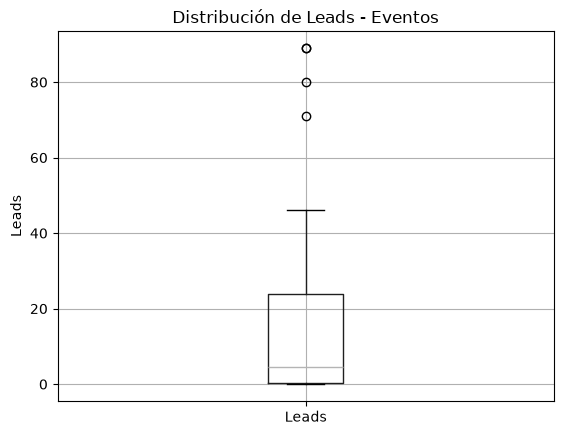

In [36]:
# Gráfico de caja para identificar outliers del canal Eventos

df_leads[df_leads["Canal"] == "Eventos"].boxplot(column="Leads")

plt.title("Distribución de Leads - Eventos")
plt.ylabel("Leads")

plt.show()

In [43]:
# Identificamos los outliers del canal eventos

eventos = df_leads[df_leads["Canal"] == "Eventos"]["Leads"]

Q1 = eventos.quantile(0.25)
Q3 = eventos.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_eventos = df_leads[(df_leads["Canal"] == "Eventos") & ((df_leads["Leads"] < limite_inferior) |(df_leads["Leads"] > limite_superior))]

outliers_eventos

,Mes_num,Canal,Leads
65,6,Eventos,71
76,17,Eventos,80
84,25,Eventos,89
86,27,Eventos,89


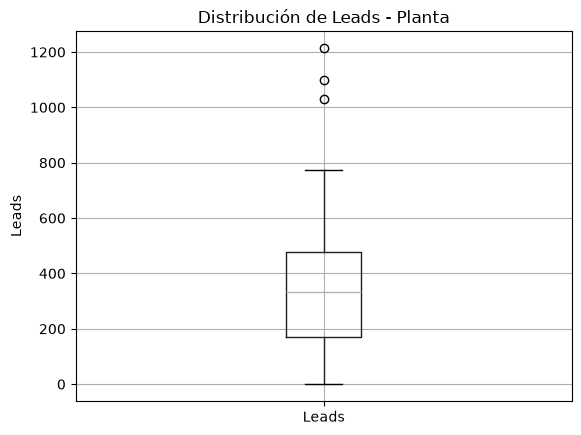

In [31]:
# Gráfico de caja para identificar outliers del canal Planta

df_leads[df_leads["Canal"] == "Planta"].boxplot(column="Leads")

plt.title("Distribución de Leads - Planta")
plt.ylabel("Leads")

plt.show()

In [38]:
# Identificamos los outliers del canal Piso

planta = df_leads[df_leads["Canal"] == "Planta"]["Leads"]

Q1 = planta.quantile(0.25)
Q3 = planta.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_planta = df_leads[(df_leads["Canal"] == "Planta") & ((df_leads["Leads"] < limite_inferior) |(df_leads["Leads"] > limite_superior))]

outliers_planta

,Mes_num,Canal,Leads
98,9,Planta,1030
99,10,Planta,1214
100,11,Planta,1098


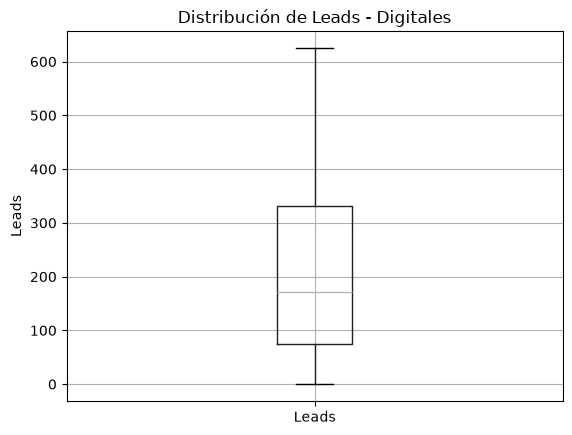

In [33]:
# Gráfico de caja para identificar outliers del canal Digitales

df_leads[df_leads["Canal"] == "Digitales"].boxplot(column="Leads")

plt.title("Distribución de Leads - Digitales")
plt.ylabel("Leads")

plt.show()

In [41]:
# Identificamos los outliers del canal Piso

digitales = df_leads[df_leads["Canal"] == "Digitales"]["Leads"]

Q1 = digitales.quantile(0.25)
Q3 = digitales.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_digitales = df_leads[(df_leads["Canal"] == "Digitales") & ((df_leads["Leads"] < limite_inferior) |(df_leads["Leads"] > limite_superior))]

outliers_digitales

,Mes_num,Canal,Leads


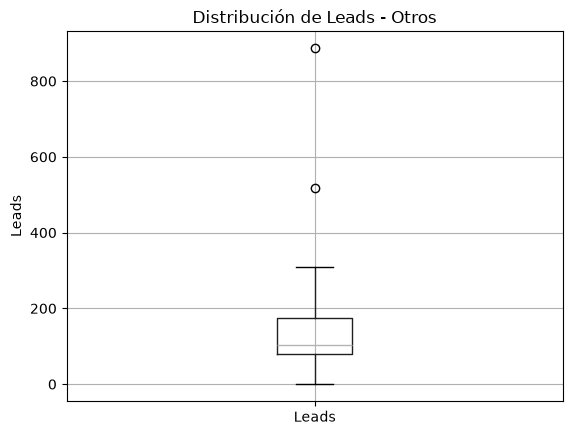

In [34]:
# Gráfico de caja para identificar outliers del canal Otros

df_leads[df_leads["Canal"] == "Otros"].boxplot(column="Leads")

plt.title("Distribución de Leads - Otros")
plt.ylabel("Leads")

plt.show()

In [42]:

otros = df_leads[df_leads["Canal"] == "Otros"]["Leads"]

Q1 = otros.quantile(0.25)
Q3 = otros.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_otros = df_leads[(df_leads["Canal"] == "Otros") & ((df_leads["Leads"] < limite_inferior) |(df_leads["Leads"] > limite_superior))]

outliers_otros

,Mes_num,Canal,Leads
157,8,Otros,887
159,10,Otros,518


Se utilizó el método IQR para identificar valores atípicos en la generación de leads de cada canal. Los valores detectados se conservaron debido a que representan variaciones reales de la actividad comercial y no se encontró evidencia de que correspondieran a errores de captura.

**¿De qué canales provienen principalmente los leads y cuáles están impulsando el crecimiento de la captación?**

In [44]:
df_correlacion2 = df_leads.pivot( index="Mes_num", columns="Canal", values="Leads").reset_index()

df_correlacion2.head()

Canal,Mes_num,Digitales,Eventos,Otros,Piso,Planta,Plazas
0,1,0,0,0,0,0,0
1,2,6,7,195,329,6,0
2,3,5,0,102,19,52,0
3,4,18,5,165,76,127,25
4,5,69,0,178,87,60,28


In [45]:
df_correlacion2.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Mes_num    30 non-null     int64
 1   Digitales  30 non-null     int64
 2   Eventos    30 non-null     int64
 3   Otros      30 non-null     int64
 4   Piso       30 non-null     int64
 5   Planta     30 non-null     int64
 6   Plazas     30 non-null     int64
dtypes: int64(7)
memory usage: 1.8 KB


In [46]:
df_correlacion2["Total_leads"] = (df_correlacion2["Piso"] + df_correlacion2["Plazas"] + df_correlacion2["Eventos"] + df_correlacion2["Planta"] + df_correlacion2["Digitales"] +
df_correlacion2["Otros"])

In [47]:
df_correlacion2.head()

Canal,Mes_num,Digitales,Eventos,Otros,Piso,Planta,Plazas,Total_leads
0,1,0,0,0,0,0,0,0
1,2,6,7,195,329,6,0,543
2,3,5,0,102,19,52,0,178
3,4,18,5,165,76,127,25,416
4,5,69,0,178,87,60,28,422


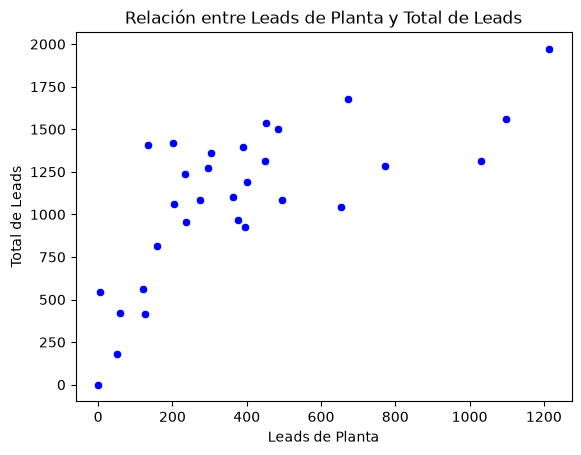

In [49]:
sns.scatterplot(x="Planta", y="Total_leads", color="blue", data=df_correlacion2)

plt.title("Relación entre Leads de Planta y Total de Leads")
plt.xlabel("Leads de Planta")
plt.ylabel("Total de Leads")

plt.show()

In [50]:
Vars_Indep = df_correlacion2[["Planta"]]

Var_Dep = df_correlacion2["Total_leads"]

In [51]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()

In [52]:
#Ajustamos el modelo con las variables antes declaradas
model2.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Planta']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,692.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [53]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model2.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Planta'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.01315535]),
 'rank_': np.int64(1),
 'singular_': array([1686.2178586]),
 'intercept_': np.float64(692.5869553453274)}

Total de Leads = 692.58695534532 + 1.013155 (leads de planta)

In [54]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model2.score(Vars_Indep,Var_Dep)

0.49223959059009614

In [ ]:
#Predecimos los valores

y_pred2= model2.predict(X=df_correlacion2[['Planta']])
y_pred2

array([ 692.58695535,  698.66588742,  745.27103336,  821.25768434,
        753.37627613, 1073.53336561,  932.70477245,  829.36292712,
       1736.13696219, 1922.55754594, 1805.03152575, 1474.74288281,
       1355.19055193,  816.19190761, 1091.77016185, 1194.09885184,
        852.66550008,  971.20467562, 1001.59933601,  897.24433533,
       1061.37550145, 1098.86224927,  899.27064602, 1150.53317194,
       1182.95414303,  993.49409324, 1374.44050351, 1088.73069581,
        928.65215107, 1147.4937059 ])

In [57]:
#Insertamos la columna de predicciones en el DataFrame
df_correlacion2.insert(0, 'Predicciones', y_pred2)
df_correlacion2

Canal,Predicciones,Mes_num,Digitales,Eventos,Otros,Piso,Planta,Plazas,Total_leads
0,692.586955,1,0,0,0,0,0,0,0
1,698.665887,2,6,7,195,329,6,0,543
2,745.271033,3,5,0,102,19,52,0,178
3,821.257684,4,18,5,165,76,127,25,416
4,753.376276,5,69,0,178,87,60,28,422
5,1073.533366,6,87,71,310,55,376,68,967
6,932.704772,7,113,4,214,92,237,294,954
7,829.362927,8,57,5,887,77,135,248,1409
8,1736.136962,9,107,1,68,57,1030,52,1315
9,1922.557546,10,139,0,518,43,1214,59,1973


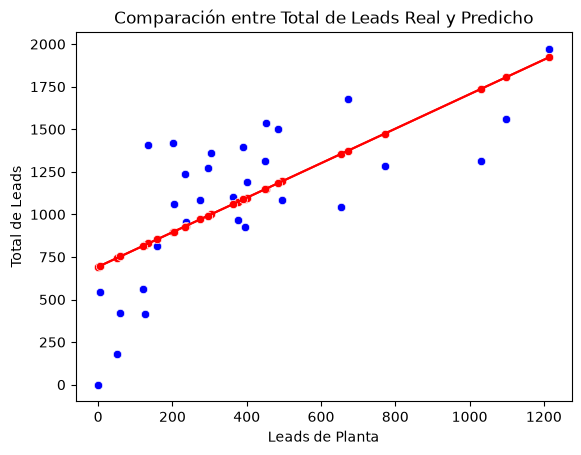

In [59]:
#Visualizamos la gráfica comparativa entre el total real y el total predecido

sns.scatterplot(x='Planta', y='Total_leads', color="blue", data=df_correlacion2)
sns.scatterplot(x='Planta', y='Predicciones', color="red", data=df_correlacion2)
sns.lineplot(x='Planta', y='Predicciones', color="red", data=df_correlacion2)

plt.title("Comparación entre Total de Leads Real y Predicho")
plt.xlabel("Leads de Planta")
plt.ylabel("Total de Leads")
plt.show()


In [61]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter2=model2.score(X=Vars_Indep, y=Var_Dep)
coef_Deter2

0.49223959059009614

In [62]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter2)
coef_Correl

np.float64(0.7015978838266946)

In [63]:
# Seleccionamos las variables numéricas
# y eliminamos Predicciones del análisis de correlación

df_numerico2 = df_correlacion2.select_dtypes(include="number").drop(columns=["Predicciones"], errors="ignore")

df_numerico2.head()

Canal,Mes_num,Digitales,Eventos,Otros,Piso,Planta,Plazas,Total_leads
0,1,0,0,0,0,0,0,0
1,2,6,7,195,329,6,0,543
2,3,5,0,102,19,52,0,178
3,4,18,5,165,76,127,25,416
4,5,69,0,178,87,60,28,422


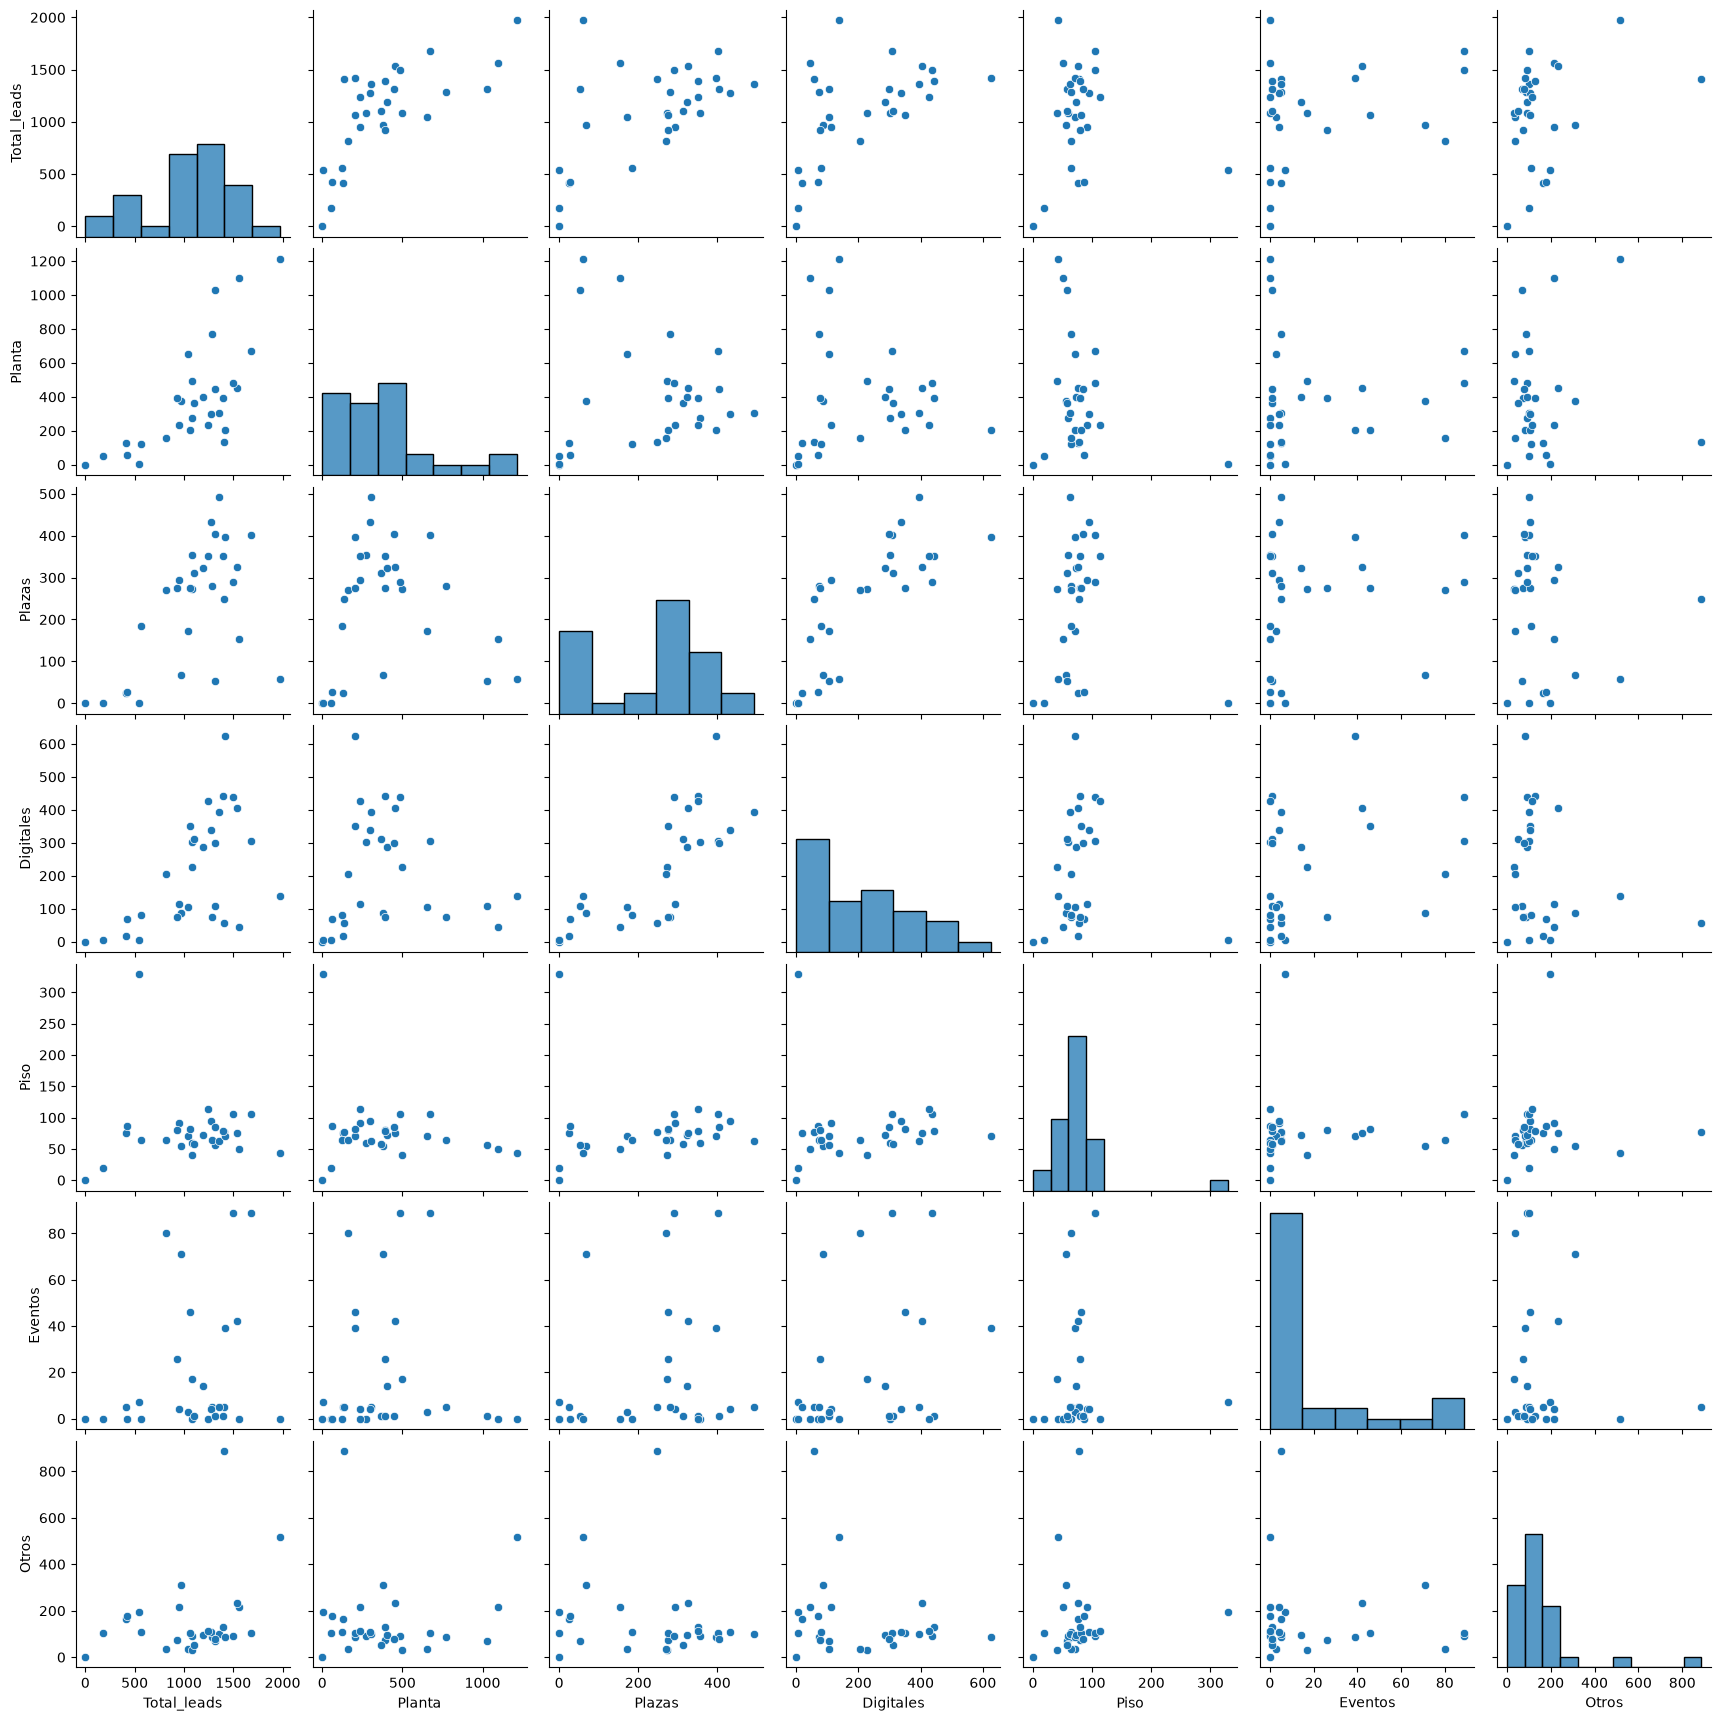

In [64]:
sns.pairplot(df_numerico2[["Total_leads", "Planta", "Plazas", "Digitales", "Piso", "Eventos", "Otros"]])

plt.show()

In [65]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables 
Corr_Factors2= df_numerico2[["Total_leads", "Planta", "Plazas", "Digitales", "Piso", "Eventos", "Otros"]].corr()
Corr_Factors2

Canal,Total_leads,Planta,Plazas,Digitales,Piso,Eventos,Otros
Canal,,,,,,,
Total_leads,1.000000,0.701598,0.571863,0.550804,-0.019913,0.225564,0.298424
Planta,0.701598,1.000000,0.016554,-0.008522,-0.224559,0.000719,0.088146
Plazas,0.571863,0.016554,1.000000,0.784427,-0.033115,0.202378,-0.168488
Digitales,0.550804,-0.008522,0.784427,1.000000,0.001117,0.322977,-0.235735
Piso,-0.019913,-0.224559,-0.033115,0.001117,1.000000,0.069871,0.063408
Eventos,0.225564,0.000719,0.202378,0.322977,0.069871,1.000000,-0.084340
Otros,0.298424,0.088146,-0.168488,-0.235735,0.063408,-0.084340,1.000000


In [67]:
# Encontramos el valor absoluto de todas las correlaciones

Corr_Factors2_abs = abs(Corr_Factors2)
Corr_Factors2_abs

Canal,Total_leads,Planta,Plazas,Digitales,Piso,Eventos,Otros
Canal,,,,,,,
Total_leads,1.000000,0.701598,0.571863,0.550804,0.019913,0.225564,0.298424
Planta,0.701598,1.000000,0.016554,0.008522,0.224559,0.000719,0.088146
Plazas,0.571863,0.016554,1.000000,0.784427,0.033115,0.202378,0.168488
Digitales,0.550804,0.008522,0.784427,1.000000,0.001117,0.322977,0.235735
Piso,0.019913,0.224559,0.033115,0.001117,1.000000,0.069871,0.063408
Eventos,0.225564,0.000719,0.202378,0.322977,0.069871,1.000000,0.084340
Otros,0.298424,0.088146,0.168488,0.235735,0.063408,0.084340,1.000000


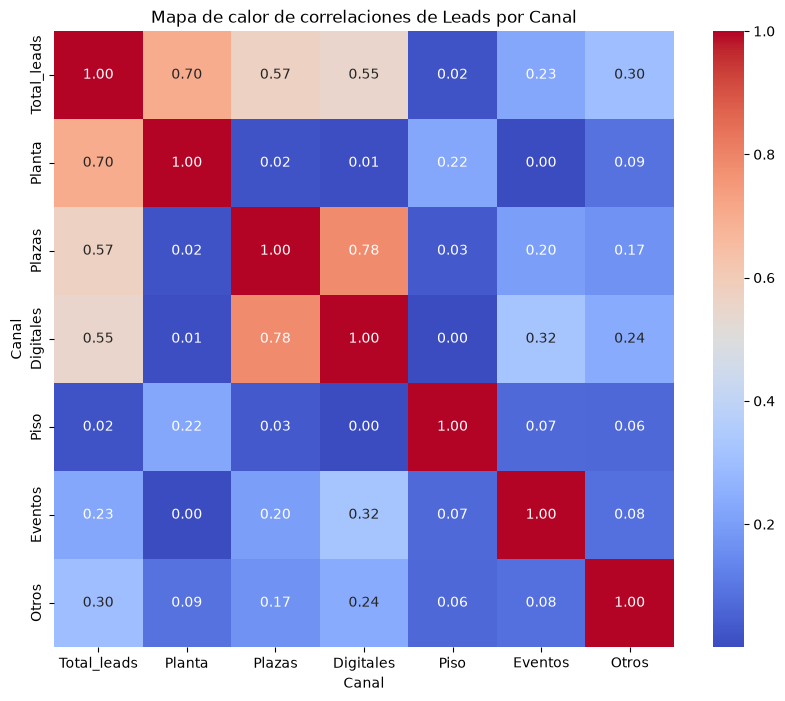

In [71]:
#Graficamos el mapa de calor de los coeficientes de correlación 
plt.figure(figsize=(10, 8))

Heat_Map= sns.heatmap(Corr_Factors2_abs, cmap = 'coolwarm', annot=True, fmt=".2f")  
plt.title("Mapa de calor de correlaciones de Leads por Canal")
Heat_Map
plt.show()